In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
df = pd.read_csv("data/final_matrix.csv")
df.drop("region", axis=1, inplace=True)

In [67]:
ohe_cols = ["Element", "Weapon Type", "Ascension Bonus", "bodyType", "Fielder-Type"]

df_encoded = pd.get_dummies(df, columns=ohe_cols, prefix=ohe_cols, drop_first=False)

In [68]:
bool_cols = df_encoded.select_dtypes(include=["bool"]).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

In [69]:

df_encoded.drop("name", axis=1, inplace=True)
corr_vector = df_encoded.corr()["pull_number"].sort_values()


In [70]:
top10 = corr_vector.reindex(
    corr_vector.abs().sort_values(ascending=False).index
).iloc[1:15] 

In [71]:
top10

star                                 -0.856336
own                                   0.848987
Ascension Bonus_Critical Damage      -0.347750
Ascension Bonus_Critical Rate        -0.334447
Ascension Bonus_Attack%               0.304802
Fielder-Type_On-Field                -0.278173
Fielder-Type_Off-Field                0.278173
DPS                                  -0.229798
Ascension Bonus_HP%                   0.181145
Ascension Bonus_Anemo Damage Bonus    0.177882
Survivability                         0.162186
use                                  -0.158828
Ascension Bonus_Hydro Damage Bonus   -0.146088
bodyType_BOY                          0.144342
Name: pull_number, dtype: float64

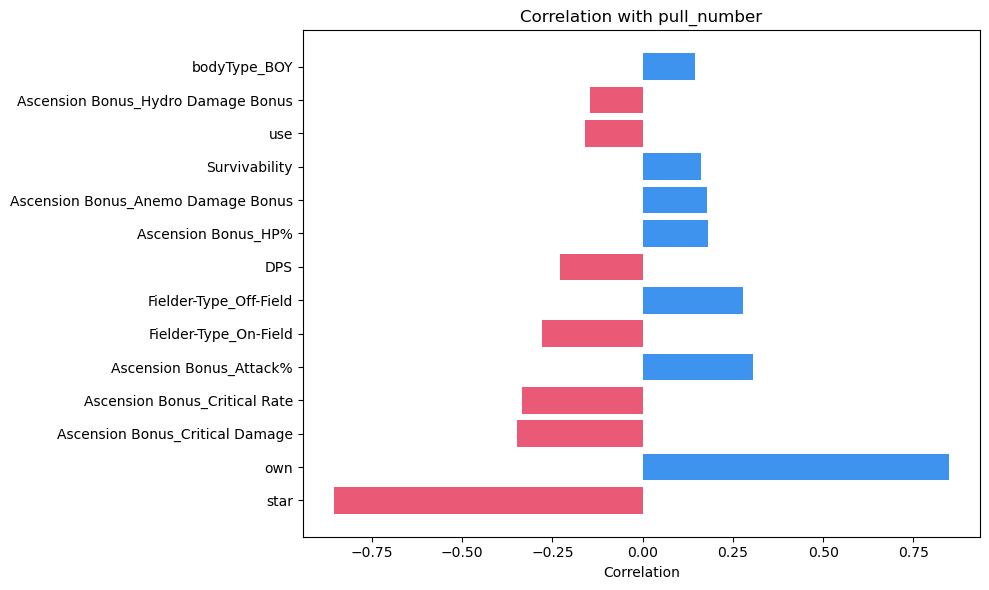

In [76]:
colors = ["#ea5976" if v < 0 else "#3e93ee" for v in top10.values]

plt.figure(figsize=(10, 6))
plt.barh(top10.index, top10.values,color=colors)
plt.title("Correlation with pull_number")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

The higher star means its rarer, so less pulls.

more people who own a character would have pulled it more duh

Perhaps people really don't care about crit stats.

and more people care about off-field support roles